# Cleaning des données 2021-2025

* Nettoyage des ccolonnes non utiles pour le Tableaud de bord
* Création de nouvelles colonnes pour le Tableau de bord
* Dernière vérification des données
* Renommage des colonnes avant export final

### Import si usage Drive

In [35]:
from google.colab import drive
import os
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Liora'

# Vérification si le dossier existe et affichage du contenu
if os.path.exists(base_path):
    print("Accès réussi au dossier Liora !")
    print("Contenu du dossier :", os.listdir(base_path))

    # Se déplacer dans ce dossier pour faciliter les imports suivants
    os.chdir(base_path)
else:
    print("Le dossier n'a pas été trouvé. Vérifie bien l'orthographe (majuscules/minuscules) ou si le dossier est dans un sous-dossier.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Accès réussi au dossier Liora !
Contenu du dossier : ['LFB Mobilisation data from January 2009 - 2014.xlsx', 'Mobilisations Metadata.xlsx', 'Incident Metadata.xlsx', 'LFB Incident data from 2024 onwards.xlsx', 'LFB Incident data from 2018 - 2023.xlsx', 'LFB Mobilisation data from 2015 - 2020.xlsx', 'LFB Mobilisation data from 2025.csv', 'LFB Mobilisation data from 2021 - 2024.csv', 'LFB Incident data from 2018 - 2023.csv', 'LFB Incident data from 2024 onwards.csv', 'LFB Mobilisation data from January 2009 - 2014.csv', 'LFB Mobilisation data from 2015 - 2020.csv', 'Metadata Incident_complet.docx', 'Metadata_Mobilisation_complet.docx', 'LFB Incident data from 2009 - 2017.csv', 'all_mobilisations.csv', 'mobilisation_completv26pm.csv', 'Incident_complet.csv', 'incident_complet.csv', 'mobilisation_complet.csv', 'incident_complet_2021_2025.parquet', 'mobilisation_c

### Import si usage local

In [36]:
base_path = ""

### Import Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install fastparquet
import plotly.express as px

### Lecture des fichiers

In [38]:
incident_complet = pd.read_parquet('incident_complet_2021_2025.parquet', engine='fastparquet')
mobilisation_complet = pd.read_parquet('mobilisation_complet_2021_2025.parquet', engine='fastparquet')

In [39]:
mobilisation_complet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930521 entries, 0 to 930520
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   IncidentNumber            930521 non-null  object        
 1   CalYear                   930521 non-null  Int64         
 2   HourOfCall                930521 non-null  Int64         
 3   ResourceMobilisationId    930521 non-null  Int64         
 4   Resource_Code             930521 non-null  object        
 5   PerformanceReporting      930521 non-null  object        
 6   DateAndTimeMobilised      930521 non-null  datetime64[ns]
 7   DateAndTimeMobile         926390 non-null  datetime64[ns]
 8   DateAndTimeArrived        930521 non-null  datetime64[ns]
 9   TurnoutTimeSeconds        926371 non-null  Int64         
 10  TravelTimeSeconds         926358 non-null  Int64         
 11  AttendanceTimeSeconds     930521 non-null  Int64         
 12  Da

### Incidents : nouvelles colonnes et colonnes à supprimer
- DayOfWeekofCall -> Jour de la semaine de l'appel
- MonthofCall -> Mois de la semaine de l'appel
- Incident Subgroup -> contenu de "StopCodeDescription" si IncidentGroup est "False Alarm" ou "Fire", contenu de "SpecialServiceType" si IncidentGroup est "Special Service"
- IncidentWithMobilisation = 1 si "FirstPumpArriving_AttendanceTime" n'est pas nul, sinon 0
- Supprimer : Easting_m
- Supprimer : Northing_m
- Supprimer : Latitude
- Supprimer : Longitude

In [40]:
incident_complet.head()

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls
0,000004-01012021,2021-01-01,2021,00:06:47,0,False Alarm,AFA,,Non Residential,Single shop,...,181.0,Hornsey,NaN,,1.0,1.0,1,60,346,1.0
1,000005-01012021,2021-01-01,2021,00:07:46,0,Fire,Secondary Fire,,Outdoor,Tree scrub,...,250.0,Woodford,NaN,,1.0,1.0,1,60,346,1.0
2,000006-01012021,2021-01-01,2021,00:08:21,0,False Alarm,False alarm - Good intent,,Outdoor,Road surface/pavement,...,376.0,Dagenham,NaN,,1.0,1.0,1,60,346,1.0
3,000007-01012021,2021-01-01,2021,00:12:16,0,False Alarm,False alarm - Good intent,,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,...,409.0,Wandsworth,445.0,Fulham,5.0,5.0,5,99,571,4.0
4,000009-01012021,2021-01-01,2021,00:14:51,0,Fire,Primary Fire,,Road Vehicle,Car,...,362.0,Stratford,NaN,,1.0,1.0,1,60,346,2.0


In [41]:
# création du masque "uniquement special service"
special_service = incident_complet['IncidentGroup'] == 'Special Service'

# remplacement des valeurs StopCodeDescription ('Special service')  par la valeur de 'SpecialServiceType'
incident_complet.loc[special_service,'StopCodeDescription' ] = incident_complet.loc[special_service,'SpecialServiceType' ]
incident_complet[special_service].head()

,IncidentNumber,DateOfCall,CalYear,TimeOfCall,HourOfCall,IncidentGroup,StopCodeDescription,SpecialServiceType,PropertyCategory,PropertyType,...,FirstPumpArriving_AttendanceTime,FirstPumpArriving_DeployedFromStation,SecondPumpArriving_AttendanceTime,SecondPumpArriving_DeployedFromStation,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls
14,000032-01012021,2021-01-01,2021,00:23:00,0,Special Service,Lift Release,Lift Release,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,...,720.0,Northolt,47.0,Harrow,1.0,2.0,2,60,346,2.0
46,000098-01012021,2021-01-01,2021,01:05:35,1,Special Service,Lift Release,Lift Release,Dwelling,Purpose Built Flats/Maisonettes - 4 to 9 storeys,...,516.0,Plumstead,NaN,,1.0,1.0,1,60,346,3.0
64,000148-01012021,2021-01-01,2021,02:13:27,2,Special Service,RTC,RTC,Road Vehicle,Car,...,209.0,Hammersmith,NaN,,1.0,1.0,1,60,346,1.0
67,000152-01012021,2021-01-01,2021,02:18:38,2,Special Service,RTC,RTC,Road Vehicle,Car,...,221.0,Shadwell,242.0,Whitechapel,2.0,2.0,2,60,346,1.0
68,000154-01012021,2021-01-01,2021,02:33:03,2,Special Service,Effecting entry/exit,Effecting entry/exit,Dwelling,Purpose Built Flats/Maisonettes - 10 or more s...,...,474.0,Enfield,NaN,,1.0,1.0,1,60,346,1.0


In [42]:
# S'assurer que la colonne DateOfCall est au bon format
incident_complet['DateOfCall'] = pd.to_datetime(incident_complet['DateOfCall'])

# Création de 'IncidentWithMobilisation'
incident_complet['IncidentWithMobilisation'] = incident_complet['FirstPumpArriving_AttendanceTime'].notna().astype(int)

# Suppression des colonnes de coordonnées
cols_to_drop = ['ProperCase','Easting_m', 'Northing_m','FRS','SpecialServiceType','Latitude','Longitude', 'UPRN', 'Postcode_full']
incident_complet = incident_complet.drop(columns=cols_to_drop, errors='ignore')
#incident_complet = incident_complet.set_index('IncidentNumber')

#Visualisation du résultat
#print(incident_complet.head())
print(incident_complet.info())
incident_complet.to_parquet('incident_complet_postcovid_clean.parquet', index=False)

print("Fichier sauvegardé avec succès au format Parquet !")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 633178 entries, 0 to 633177
Data columns (total 31 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   IncidentNumber                          633178 non-null  object        
 1   DateOfCall                              633178 non-null  datetime64[ns]
 2   CalYear                                 633178 non-null  int64         
 3   TimeOfCall                              633178 non-null  object        
 4   HourOfCall                              633178 non-null  int64         
 5   IncidentGroup                           633178 non-null  object        
 6   StopCodeDescription                     633178 non-null  object        
 7   PropertyCategory                        633178 non-null  object        
 8   PropertyType                            633178 non-null  object        
 9   AddressQualifier                     

In [43]:
print(incident_complet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 633178 entries, 0 to 633177
Data columns (total 31 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   IncidentNumber                          633178 non-null  object        
 1   DateOfCall                              633178 non-null  datetime64[ns]
 2   CalYear                                 633178 non-null  int64         
 3   TimeOfCall                              633178 non-null  object        
 4   HourOfCall                              633178 non-null  int64         
 5   IncidentGroup                           633178 non-null  object        
 6   StopCodeDescription                     633178 non-null  object        
 7   PropertyCategory                        633178 non-null  object        
 8   PropertyType                            633178 non-null  object        
 9   AddressQualifier                     

### Mobilisations : nouvelles colonnes et suppression de colonnes
- DayOfWeekofMobilised -> Jour de la semaine de la mobilisation
- MonthMobilised -> Mois de la mobilisation
- supprimer DateAndTimeReturned
- si DelayCodeId is NULL -> mettre -1
- si DelayCode_Description is NULL -> mettre "Sans délai"

In [44]:

# Dates
mobilisation_complet['DateAndTimeMobilised'] = pd.to_datetime(mobilisation_complet['DateAndTimeMobilised'])

# Conversion en numérique pour identifier les vrais NaN
mobilisation_complet['DelayCodeId'] = pd.to_numeric(mobilisation_complet['DelayCodeId'], errors='coerce')

# Définition des conditions pour les NaN
cond_moins_6min = (mobilisation_complet['DelayCodeId'].isna()) & (mobilisation_complet['PumpOrder'] == 1) & (mobilisation_complet['AttendanceTimeSeconds'] <= 360)
cond_moins_8min = (mobilisation_complet['DelayCodeId'].isna()) & (mobilisation_complet['PumpOrder'] == 2) & (mobilisation_complet['AttendanceTimeSeconds'] <= 480)
cond_autres_nan = (mobilisation_complet['DelayCodeId'].isna())

# Application de la logique :
# Si cond_moins_6min OU cond_moins_8min -> -1
# Sinon, si c'est toujours un NaN -> 12
# Sinon, on garde la valeur existante
mobilisation_complet['DelayCodeId'] = np.select(
    [cond_moins_6min | cond_moins_8min, cond_autres_nan],
    [-1, 12],
    default=mobilisation_complet['DelayCodeId']
)

# Mise à jour de la description pour les nouveaux codes 12
mobilisation_complet.loc[(mobilisation_complet['DelayCodeId'] == 12), 'DelayCode_Description'] = 'Not held up'

# Conversion finale en Int64
mobilisation_complet = mobilisation_complet.astype({'DelayCodeId': 'int64'})

# Nettoyage des descriptions
mobilisation_complet['DelayCode_Description'] = (
    mobilisation_complet['DelayCode_Description']
    .astype(str)
    .replace(['nan', 'None', 'None '], 'Sans délai')
)

# Suppression de la colonne demandée
if 'DateAndTimeReturned' in mobilisation_complet.columns:
    mobilisation_complet = mobilisation_complet.drop(columns=['DateAndTimeReturned'])

# Export au format Parquet
mobilisation_complet.to_parquet('mobilisation_complet_postcovid_clean.parquet', index=False)
print("Fichier Mobilisations sauvegardé avec succès.")
mobilisation_complet.head()
mobilisation_complet.info()


Fichier Mobilisations sauvegardé avec succès.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930521 entries, 0 to 930520
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   IncidentNumber            930521 non-null  object        
 1   CalYear                   930521 non-null  Int64         
 2   HourOfCall                930521 non-null  Int64         
 3   ResourceMobilisationId    930521 non-null  Int64         
 4   Resource_Code             930521 non-null  object        
 5   PerformanceReporting      930521 non-null  object        
 6   DateAndTimeMobilised      930521 non-null  datetime64[ns]
 7   DateAndTimeMobile         926390 non-null  datetime64[ns]
 8   DateAndTimeArrived        930521 non-null  datetime64[ns]
 9   TurnoutTimeSeconds        926371 non-null  Int64         
 10  TravelTimeSeconds         926358 non-null  Int64         
 11  AttendanceTimeSecon

Valeurs NaN

- TurnoutTimeSeconds  : calculer la moyenne de TurnoutTimeSeconds  par DeployedFromStation_Name et remplir les valeurs Nan avec ces moyennes
- TravelTimeSeconds  : calculer la moyenne de TravelTimeSeconds  par DeployedFromStation_Name et remplir les valeurs Nan avec ces moyennes
- DateAndTimeMobile : remplir les valeurs NaN avec le résultat du calcul (DateAndTimeMobilised  +TurnoutTimeSeconds)

In [45]:
# Type float
mobilisation_complet['TurnoutTimeSeconds'] = pd.to_numeric(mobilisation_complet['TurnoutTimeSeconds'], errors='coerce').astype(float)
mobilisation_complet['TravelTimeSeconds'] = pd.to_numeric(mobilisation_complet['TravelTimeSeconds'], errors='coerce').astype(float)

# Moyennes
mobilisation_complet['TurnoutTimeSeconds'] = mobilisation_complet['TurnoutTimeSeconds'].fillna(
    mobilisation_complet.groupby('DeployedFromStation_Name')['TurnoutTimeSeconds'].transform('mean')
)

mobilisation_complet['TravelTimeSeconds'] = mobilisation_complet['TravelTimeSeconds'].fillna(
    mobilisation_complet.groupby('DeployedFromStation_Name')['TravelTimeSeconds'].transform('mean')
)

# Si une station n'a aucune donnée -> moyenne globale
mobilisation_complet['TurnoutTimeSeconds'] = mobilisation_complet['TurnoutTimeSeconds'].fillna(mobilisation_complet['TurnoutTimeSeconds'].mean())
mobilisation_complet['TravelTimeSeconds'] = mobilisation_complet['TravelTimeSeconds'].fillna(mobilisation_complet['TravelTimeSeconds'].mean())

# AttendanceTimeSeconds : temps d'intervention total est la somme du temps de préparation et du trajet
mobilisation_complet['AttendanceTimeSeconds'] = mobilisation_complet['TurnoutTimeSeconds'] + mobilisation_complet['TravelTimeSeconds']

# Calcul de DateAndTimeMobile
mobilisation_complet['DateAndTimeMobilised'] = pd.to_datetime(mobilisation_complet['DateAndTimeMobilised'])
mobilisation_complet['DateAndTimeMobile'] = pd.to_datetime(mobilisation_complet['DateAndTimeMobile'])
mask_nan = mobilisation_complet['DateAndTimeMobile'].isna()

# On complète DateAndTimeMobile
mobilisation_complet.loc[mask_nan, 'DateAndTimeMobile'] = (
    mobilisation_complet.loc[mask_nan, 'DateAndTimeMobilised'] +
    pd.to_timedelta(mobilisation_complet.loc[mask_nan, 'TurnoutTimeSeconds'].fillna(0), unit='s')
)

# On convertit les trois colonnes de temps en Int64 (nullable integer) pour Power BI
mobilisation_complet['TurnoutTimeSeconds'] = mobilisation_complet['TurnoutTimeSeconds'].round().astype('Int64')
mobilisation_complet['TravelTimeSeconds'] = mobilisation_complet['TravelTimeSeconds'].round().astype('Int64')
mobilisation_complet['AttendanceTimeSeconds'] = mobilisation_complet['AttendanceTimeSeconds'].round().astype('Int64')

# Export au format Parquet
mobilisation_complet.to_parquet('mobilisation_complet_postcovid_clean.parquet', index=False)
print("Fichier Mobilisations sauvegardé avec succès.")



Fichier Mobilisations sauvegardé avec succès.


### Mobilisations after/before pour vérification

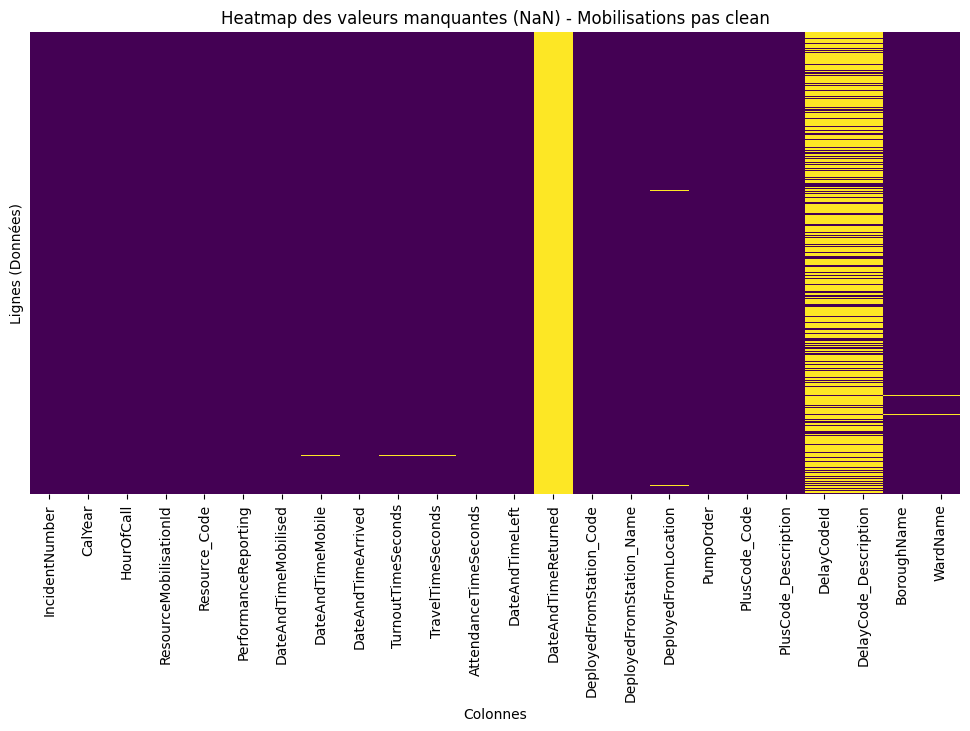

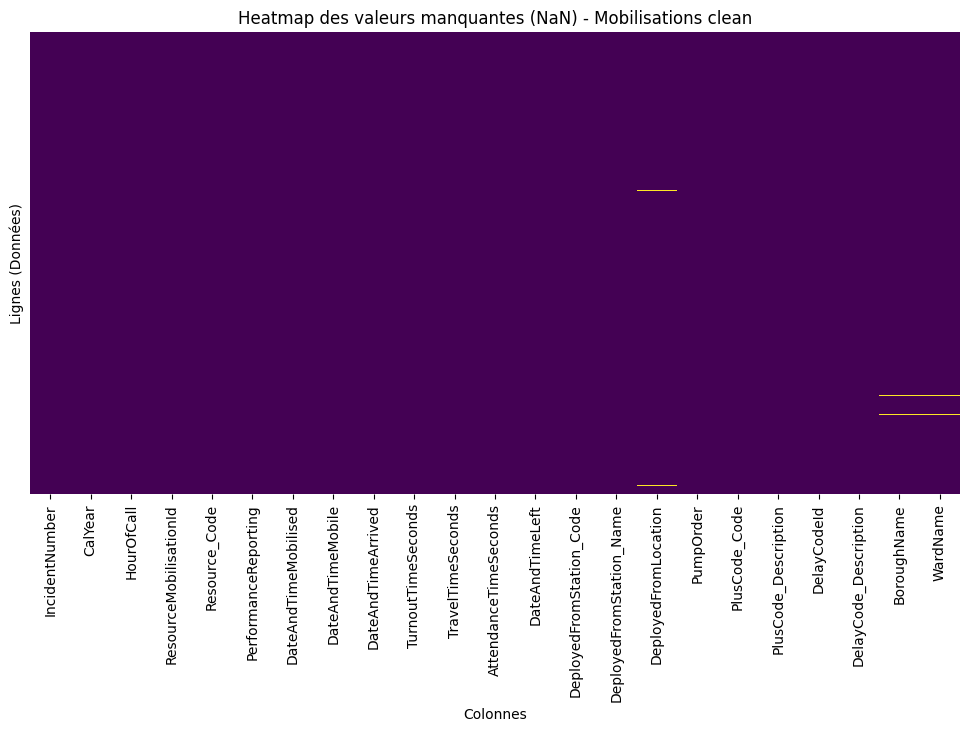

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930521 entries, 0 to 930520
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   IncidentNumber            930521 non-null  object        
 1   CalYear                   930521 non-null  Int64         
 2   HourOfCall                930521 non-null  Int64         
 3   ResourceMobilisationId    930521 non-null  Int64         
 4   Resource_Code             930521 non-null  object        
 5   PerformanceReporting      930521 non-null  object        
 6   DateAndTimeMobilised      930521 non-null  datetime64[ns]
 7   DateAndTimeMobile         930521 non-null  datetime64[ns]
 8   DateAndTimeArrived        930521 non-null  datetime64[ns]
 9   TurnoutTimeSeconds        930521 non-null  Int64         
 10  TravelTimeSeconds         930521 non-null  Int64         
 11  AttendanceTimeSeconds     930521 non-null  Int64         
 12  Da

In [46]:
mobilisation_complet_pasclean = pd.read_parquet('mobilisation_complet_2021_2025.parquet', engine='fastparquet')
mobilisation_complet_clean = pd.read_parquet('mobilisation_complet_postcovid_clean.parquet', engine='fastparquet')

#  Configuration de la taille de la figure avant cleaning
plt.figure(figsize=(12, 6))
sns.heatmap(mobilisation_complet_pasclean.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap des valeurs manquantes (NaN) - Mobilisations pas clean')
plt.xlabel('Colonnes')
plt.ylabel('Lignes (Données)')
plt.show()

# Configuration de la taille de la figure après cleaning
plt.figure(figsize=(12, 6))
sns.heatmap(mobilisation_complet_clean.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap des valeurs manquantes (NaN) - Mobilisations clean')
plt.xlabel('Colonnes')
plt.ylabel('Lignes (Données)')
plt.show()

mobilisation_complet_clean.info()

### Analyse des valeurs manquantes de mobilisations

In [47]:
mobilisation_complet = pd.read_parquet('mobilisation_complet_postcovid_clean.parquet', engine='fastparquet')

# Calcul du nombre de NaN et du pourcentage par colonne
nan_counts = mobilisation_complet.isna().sum()
nan_percentages = (mobilisation_complet.isna().sum() / len(mobilisation_complet)) * 100

# Création d'un DataFrame de synthèse
nan_report = pd.DataFrame({
    'Valeurs Manquantes': nan_counts,
    'Part des NaN (%)': nan_percentages
})

# Tri pour voir les colonnes les plus problématiques en premier
nan_report = nan_report.sort_values(by='Part des NaN (%)', ascending=False)

# Affichage (uniquement les colonnes qui ont au moins un NaN)
print("=== ANALYSE DES VALEURS MANQUANTES ===")
print(nan_report[nan_report['Valeurs Manquantes'] > 0])

=== ANALYSE DES VALEURS MANQUANTES ===
                          Valeurs Manquantes  Part des NaN (%)
WardName                                4542          0.488114
BoroughName                             3532          0.379572
DeployedFromLocation                     954          0.102523
DateAndTimeLeft                          377          0.040515
DeployedFromStation_Name                   5          0.000537
DeployedFromStation_Code                   5          0.000537


### Incidents after/before

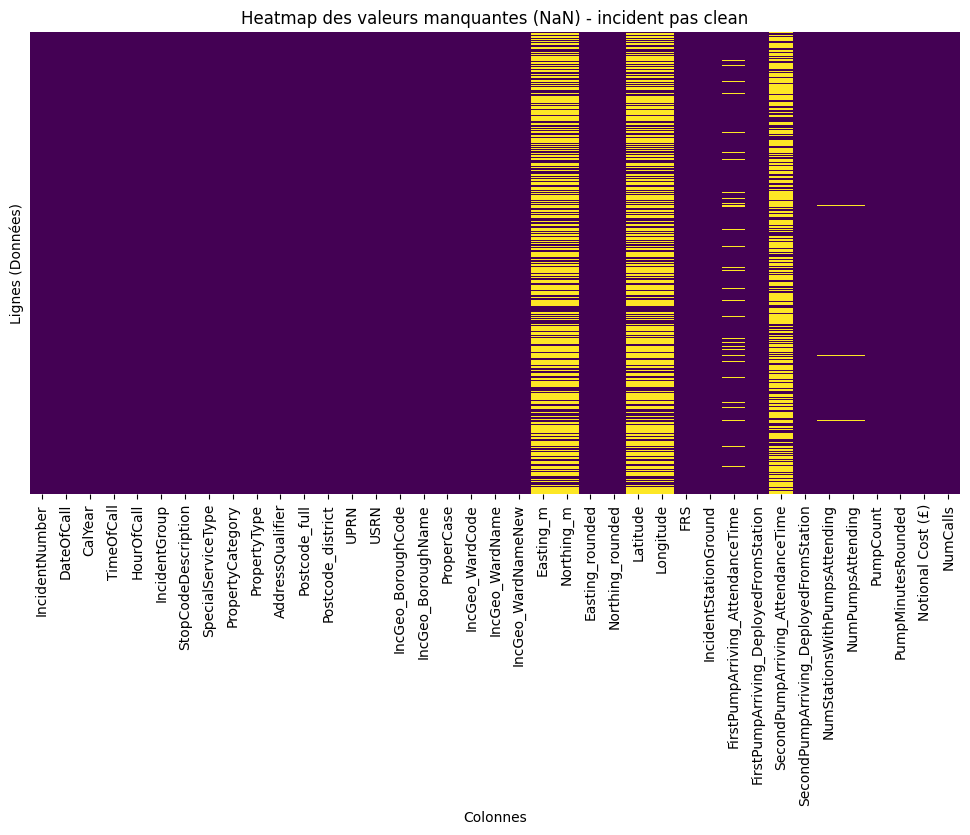

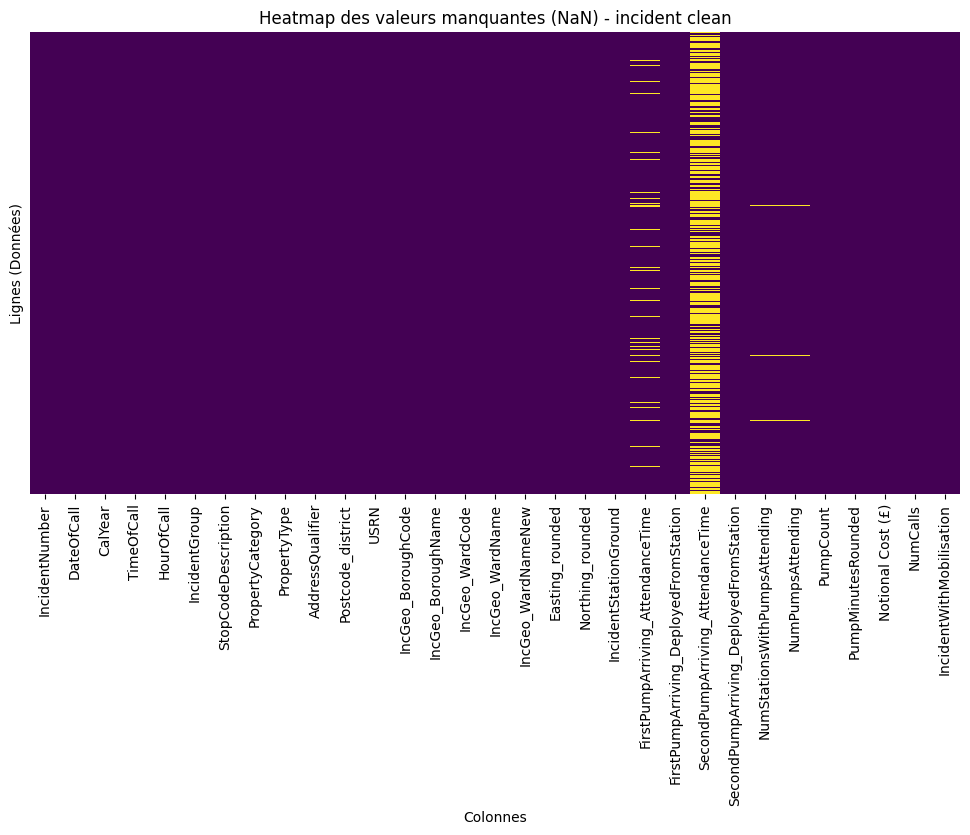

In [48]:

mobilisation_complet_pasclean = pd.read_parquet('incident_complet_2021_2025.parquet', engine='fastparquet')
mobilisation_complet_clean = pd.read_parquet('incident_complet_postcovid_clean.parquet', engine='fastparquet')

# Configuration de la taille de la figure avant cleaning
plt.figure(figsize=(12, 6))
sns.heatmap(mobilisation_complet_pasclean.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap des valeurs manquantes (NaN) - incident pas clean')
plt.xlabel('Colonnes')
plt.ylabel('Lignes (Données)')
plt.show()

# Configuration de la taille de la figure après cleaning
plt.figure(figsize=(12, 6))
sns.heatmap(mobilisation_complet_clean.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap des valeurs manquantes (NaN) - incident clean')
plt.xlabel('Colonnes')
plt.ylabel('Lignes (Données)')
plt.show()

### Check After/Before : Mobilisations

In [49]:
# Chargement
df_orig = pd.read_parquet('mobilisation_complet_2021_2025.parquet')
df_clean = pd.read_parquet('mobilisation_complet_postcovid_clean.parquet')

# Identification des colonnes numériques communes
cols_num = df_orig.select_dtypes(include=[np.number]).columns.intersection(df_clean.columns)

# Calcul des métriques
metrics = []
for col in cols_num:
    metrics.append({
        'Colonne': col,
        'Mean_Orig': df_orig[col].mean(),
        'Mean_Clean': df_clean[col].mean(),
        'Median_Orig': df_orig[col].median(),
        'Median_Clean': df_clean[col].median(),
        'Diff_Mean_%': abs((df_clean[col].mean() - df_orig[col].mean()) / df_orig[col].mean() * 100)
    })

df_compare = pd.DataFrame(metrics)
print("=== COMPARAISON DES MÉTRIQUES STATISTIQUES ===")
print(df_compare.to_string(index=False))

=== COMPARAISON DES MÉTRIQUES STATISTIQUES ===
               Colonne    Mean_Orig   Mean_Clean  Median_Orig  Median_Clean  Diff_Mean_%
               CalYear 2.023122e+03 2.023122e+03       2023.0        2023.0     0.000000
            HourOfCall 1.334716e+01 1.334716e+01         14.0          14.0     0.000000
ResourceMobilisationId 6.467577e+06 6.467577e+06    6461330.0     6461330.0     0.000000
    TurnoutTimeSeconds 7.437249e+01 7.437405e+01         71.0          71.0     0.002104
     TravelTimeSeconds 2.875865e+02 2.875965e+02        263.0         264.0     0.003454
 AttendanceTimeSeconds 3.608281e+02 3.619702e+02        338.0         339.0     0.316533
             PumpOrder 1.546318e+00 1.546318e+00          1.0           1.0     0.000000
           DelayCodeId 1.066275e+01 3.434107e+00         12.0          -1.0    67.793416


### Renommage des colonnes pour export vers Power BI

In [50]:
#Liste des colonnes à renommer
rename_dict = {

    "IncidentNumber": "Id_Incident",
    "DateOfCall": "Date_Appel",
    "CalYear": "Annee_Appel",
    "TimeOfCall": "Heure_Appel",
    "HourOfCall": "Heure_Appel_Tronquee",

    "IncidentGroup": "Type_Incident",
    "StopCodeDescription": "Sous_Type_Incident",
    "SpecialServiceType": "Sous_Type_SpecialService",

    "PropertyCategory": "Categorie_Propriete",
    "PropertyType": "Type_Propriete",
    "AddressQualifier": "Precision_Adresse",

    "Postcode_full": "Code_Postal",
    "Postcode_district": "Code_Postal_District",

    "IncGeo_BoroughCode": "Id_Borough",
    "IncGeo_BoroughName": "Nom_Borough",
    "ProperCase": "Nom_Borough_Formate",

    "IncGeo_WardCode": "Id_Ward",
    "IncGeo_WardName": "Nom_Ward",
    "IncGeo_WardNameNew": "Nom_Ward_Nouveau",

    "Easting_m": "Coord_Est_M",
    "Northing_m": "Coord_Nord_M",
    "Easting_rounded": "Coord_Est_Arrondie",
    "Northing_rounded": "Coord_Nord_Arrondie",

    "Latitude": "Latitude",
    "Longitude": "Longitude",

    "FRS": "Service_Incendie",
    "IncidentStationGround": "Nom_Station",

    "FirstPumpArriving_AttendanceTime": "Temps_Arrivee_Premiere_Pompe_Sec",
    "FirstPumpArriving_DeployedFromStation": "Station_Premiere_Pompe",

    "SecondPumpArriving_AttendanceTime": "Temps_Arrivee_Deuxieme_Pompe_Sec",
    "SecondPumpArriving_DeployedFromStation": "Station_Deuxieme_Pompe",

    "NumStationsWithPumpsAttending": "Nb_Stations_Mobilisees",
    "NumPumpsAttending": "Nb_Pompes_Mobilisees",
    "PumpCount": "Nb_Pompes_Intervenues",
    "PumpMinutesRounded": "Temps_Intervention_Pompes_Arrondi_Min",

    "Notional Cost (£)": "Cout_Estime_Gbp",
    "NumCalls": "Nb_Appels"
}
rename_dict_mobilisation = {

    "IncidentNumber": "Id_Incident",
    "CalYear": "Id_Incident",
    "HourOfCall": "Heure_Appel",

    "ResourceMobilisationId": "Id_Mobilisation_Ressource",
    "Resource_Code": "Id_Ressource",
    "PerformanceReporting": "Indicateur_Performance",

    "DateAndTimeMobilised": "Date_Heure_Mobilisation",
    "DateAndTimeMobile": "Date_Heure_Depart",
    "DateAndTimeArrived": "Date_Heure_Arrivee",

    "TurnoutTimeSeconds": "Temps_Sortie_Sec",
    "TravelTimeSeconds": "Temps_Trajet_Sec",
    "AttendanceTimeSeconds": "Temps_Delai_Intervention_Sec",

    "DateAndTimeLeft": "Date_Heure_Retour_Depart",
    "DateAndTimeReturned": "Date_Heure_Retour_Arrivee",

    "DeployedFromStation_Code": "Id_Station_Depart",
    "DeployedFromStation_Name": "Nom_Station_Depart",
    "DeployedFromLocation": "Lieu_Depart",

    "PumpOrder": "Ordre_Pompe",

    "PlusCode_Code": "Id_Code_Plus",
    "PlusCode_Description": "Description_Code_Plus",

    "DelayCodeId": "Id_Retard",
    "DelayCode_Description": "Description_Retard"
}


In [51]:

incident_nom_fichier_export = 'incident_powerbi.parquet'
mobilisation_nom_fichier_export = 'mobilisation_powerbi.parquet'

#Chargement des fichiers nettoyés
incident_complet_clean = pd.read_parquet('incident_complet_postcovid_clean.parquet')
mobilisation_complet_clean = pd.read_parquet('mobilisation_complet_postcovid_clean.parquet')

#Renommage
incident_complet_clean_renamed = incident_complet_clean.rename(columns=rename_dict)
mobilisation_complet_clean_renamed = mobilisation_complet_clean.rename(columns=rename_dict)

#Sauvergarde sous leur nom final pour utilisation dans Power BI
incident_complet_clean_renamed.to_parquet(incident_nom_fichier_export, index=False)
mobilisation_complet_clean_renamed.to_parquet(mobilisation_nom_fichier_export, index=False)

#Check
incident_complet_clean.info()
mobilisation_complet_clean.info()
incident_complet_clean_renamed.info()
mobilisation_complet_clean_renamed.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 633178 entries, 0 to 633177
Data columns (total 31 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   IncidentNumber                          633178 non-null  object        
 1   DateOfCall                              633178 non-null  datetime64[ns]
 2   CalYear                                 633178 non-null  int64         
 3   TimeOfCall                              633178 non-null  object        
 4   HourOfCall                              633178 non-null  int64         
 5   IncidentGroup                           633178 non-null  object        
 6   StopCodeDescription                     633178 non-null  object        
 7   PropertyCategory                        633178 non-null  object        
 8   PropertyType                            633178 non-null  object        
 9   AddressQualifier                     